# WESAD Dataset Exploration

This notebook is my first step into exploring the WESAD dataset.
The goal is to get a clear sense of how the data is organized, what signals are recorded, and how the emotion labels look.

## 1. Setup

In [7]:
# os helps work with file paths
import os

# pickle is for opening those .pkl files (WESAD data format)
import pickle

# pandas is the go-to for handling tables and data
import pandas as pd

# numpy makes math and signal caculations easier :)
import numpy as np

# I'll use it to visualize ECG waves
import matplotlib.pyplot as plt

# neurokit2 is the main library i'm using for ECG & HRV processing
import neurokit2 as nk

## 2. Check Dataset Structure
It'a quick look at how the dataset is organized. I want to see what subject folders exist and what’s inside one of them.

In [9]:
import os
print("Current working directory:", os.getcwd())


Current working directory: /Users/yuemingsun/Desktop/echo_hrv/notebooks


In [ ]:
# path to the dataset folder
base_path = "../data/raw/WESAD"

# list all folders that start with 'S' (each one is a subject)
subjects = sorted([s for s in os.listdir(base_path) if s.startswith("S")])

print("Subjects available:", subjects)
print("Number of subjects:", len(subjects))

# pick one sample subject and check what's inside
sample_subj = os.path.join(base_path, subjects[0])
print("\nExample subject folder:", sample_subj)
print(os.listdir(sample_subj))

Subjects available: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']
Number of subjects: 15

Example subject folder: ../data/raw/WESAD/S10
['S10.pkl', 'S10_quest.csv', 'S10_respiban.txt', 'S10_E4_Data', 'S10_readme.txt']


## 3. Load Example Subject Data
After having a brief understanding of the dataset structure in the files from last step, I'll load one subject to see what's inside. Each `.pkl` file stores all the signals recorded for that participant. I want to check what kinds of signals are available and what the emotion labels look like.

In [ ]:
# start by checking one participant's data
# Each subject folder (S2, S3...) contains a .pkl file with all signals and labels.
# I'll just pick S2.
example_file = os.path.join(base_path, "S2", "S2.pkl")

print(f"Loading data from: {example_file}")

# load the .pkl file
with open(example_file, "rb") as f:
    data = pickle.load(f, encoding="latin1")

# check the main structure 
print("\nTop-level keys:", data.keys()) 

# according to wesad_readme.pdf, "signal" contains ECG, EMG etc. and "label" contains numeric emotion labels.        
print("\nSignal categories:", data["signal"].keys())   
print("\nLabel values:", np.unique(data["label"]))     # For example, 1 = baseline; 2 = stress; 3 = amusement


Loading data from: ../data/raw/WESAD/S2/S2.pkl

Top-level keys: dict_keys(['signal', 'label', 'subject'])

Signal categories: dict_keys(['chest', 'wrist'])

Label values: [0 1 2 3 4 6 7]


## 4. Visualize ECG Signal & Emotion Labels
I’m starting with **ECG (electrocardiogram)** because it’s the foundation for **HRV analysis**, and HRV is one of the most direct physiological reflections of emotional regulation.

ECG records the heart’s electrical activity. So from ECG, I can extract each heartbeat’s timing (R–R intervals) and calculate HRV features like:
- RMSSD (short-term variability)
- LF/HF ratio (sympathetic–parasympathetic balance)
- Mean heart rate  

Later, I’ll explore how other signals like **EDA** (skin conductance) or **RESP** (breathing) can complement ECG to capture more dimensions of emotional change.


Chest signals: ['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp']


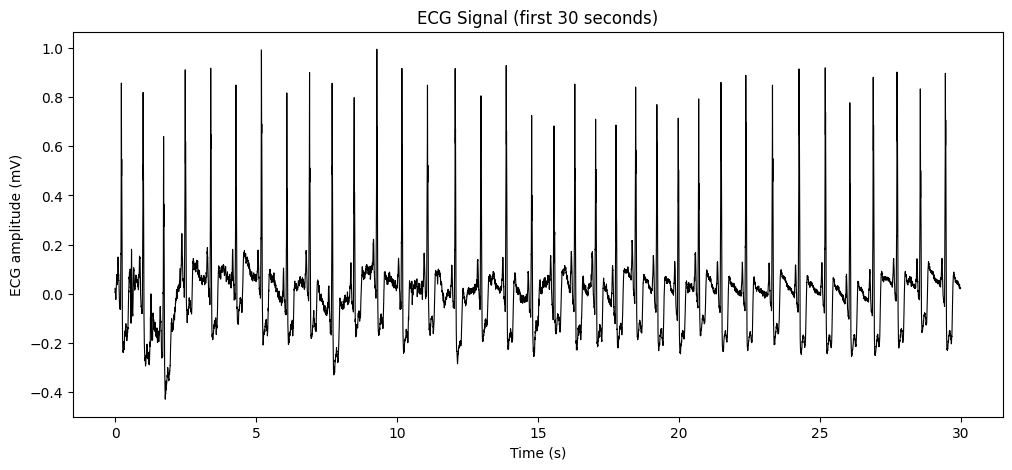

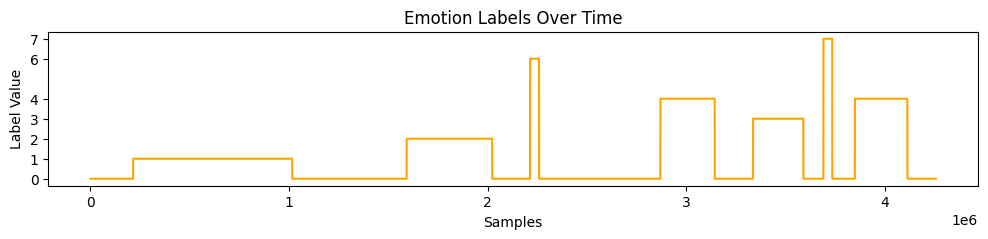

In [13]:
# this is to check what signals are available from the chest sensor
print("Chest signals:", list(data["signal"]["chest"].keys()))

# then we pick ECG
ecg_signal = data["signal"]["chest"]["ECG"]

# the numeric array tells us which emotional state corresponds to each time segment
labels = data["label"]

# 700 is the sampling frequency 
fs = 700

# create a time axis (seconds) for plotting
time = np.arange(len(ecg_signal)) / fs    # np.arange(len(ecg_signal)) makes sample indices
                                          # Dividing by fs converts indices to time in second

# plot ECG waveform. waveform shows how signal's amplitude changes over time.
plt.figure(figsize=(12, 5))
plt.plot(time[:fs*30], ecg_signal[:fs*30], color="black", linewidth=0.8)
plt.title("ECG Signal (first 30 seconds)")
plt.xlabel("Time (s)")
plt.ylabel("ECG amplitude (mV)")
plt.show()   # each spike corresponds to a heartbeat. the spacing between spikes shows HRV.

# plot emotion label timeline
plt.figure(figsize=(12, 2))
plt.plot(labels, color="orange")
plt.title("Emotion Labels Over Time")
plt.xlabel("Samples")
plt.ylabel("Label Value")  # y value is emotion state
plt.yticks([0,1,2,3,4,6,7], ["0","1","2","3","4","6","7"])
plt.show()

# later we’ll extract HRV features from the ECG and align them with these labels to train our first emotion classification model